# Quantitative analysis of simulations for different grid structures

### helper

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
smallgrid = ["./data/grid_3by3_r01.txt", "./data/grid_3by3_r02.txt", "./data/grid_3by3_r03.txt", "./data/grid_3by3_r04.txt", "./data/grid_3by3_r05.txt", "./data/grid_3by3_r06.txt", "./data/grid_3by3_r07.txt", "./data/grid_3by3_r08.txt", "./data/grid_3by3_r09.txt", "./data/grid_3by3_r10.txt"]
mediumgrid = ["./data/grid_5by5_r01.txt", "./data/grid_5by5_r02.txt", "./data/grid_5by5_r03.txt", "./data/grid_5by5_r04.txt", "./data/grid_5by5_r05.txt", "./data/grid_5by5_r06.txt", "./data/grid_5by5_r07.txt", "./data/grid_5by5_r08.txt", "./data/grid_5by5_r09.txt", "./data/grid_5by5_r10.txt"]
densegrid = ["./data/grid_dense_limit_r01.txt","./data/grid_dense_limit_r02.txt", "./data/grid_dense_limit_r03.txt", "./data/grid_dense_limit_r04.txt", "./data/grid_dense_limit_r05.txt", "./data/grid_dense_limit_r06.txt", "./data/grid_dense_limit_r07.txt", "./data/grid_dense_limit_r08.txt", "./data/grid_dense_limit_r09.txt", "./data/grid_dense_limit_r10.txt"]
closedgrid = ["./data/grid_dense_r01.txt", "./data/grid_dense_r02.txt", "./data/grid_dense_r03.txt", "./data/grid_dense_r04.txt", "./data/grid_dense_r05.txt", "./data/grid_dense_r06.txt", "./data/grid_dense_r07.txt", "./data/grid_dense_r08.txt", "./data/grid_dense_r09.txt", "./data/grid_dense_r10.txt"]

In [3]:
def load_file(path):
    df = pd.read_csv(path, sep=None, header=None, engine='python')
    df.columns = ['timesteps', 'cellid', 'cellkind', 'centroid_x', 'centroid_y']
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    df[['timesteps', 'cellid', 'cellkind']] = df[['timesteps', 'cellid', 'cellkind']].astype(int)
    return df.sort_values(['cellid', 'timesteps']).reset_index(drop=True)

def active(df):
    active = df[df['cellkind'] == 1].copy()
    active = active.sort_values(['cellid', 'timesteps'])
    return active.reset_index(drop=True)

def velocity(df):
    df['dx'] = df.groupby('cellid')['centroid_x'].diff()
    df['dy'] = df.groupby('cellid')['centroid_y'].diff()
    df['speed'] = np.sqrt(df['dx']**2 + df['dy']**2)
    df['unitvec_x'] = df['dx'] / df['speed']
    df['unitvec_y'] = df['dy'] / df['speed']
    return df.dropna()

def angle(df):
    df['prev_unitvec_x'] = df.groupby('cellid')['unitvec_x'].shift(1)
    df['prev_unitvec_y'] = df.groupby('cellid')['unitvec_y'].shift(1)
    dot_product = (df['unitvec_x'] * df['prev_unitvec_x']) + (df['unitvec_y'] * df['prev_unitvec_y'])
    df['turning_angle'] = np.arccos(np.clip(dot_product, -1.0, 1.0))
    return df

def prepare_data(path):
    df = load_file(path)
    df = active(df)
    df = velocity(df)
    df = angle(df)
    return df

def prepare_multiple_runs(paths):
    dfs = []
    for path in paths:
        df = prepare_data(path)
        dfs.append(df)
        
    return pd.concat(dfs, ignore_index=True)

In [4]:
def plot_analysis(data_dict):
    sns.set_context("notebook", font_scale=1.2)
    sns.set_style("ticks")
    _, axes = plt.subplots(1, 2, figsize=(20, 6))
    colors = {"3x3": "#440154", "5x5": "#31688e", "Dense": "#35b779", "Caged": "#8fd744"}

    # Log-Scaled Speed Distribution
    for name, df in data_dict.items():
        valid_speeds = df[df['speed'] > 1e-5]['speed']
        sns.kdeplot(valid_speeds, ax=axes[0], label=name, fill=True, log_scale=True, color=colors[name], alpha=0.3)
    axes[0].set_title("Velocity Scales (Log)")
    axes[0].set_xlabel("Speed (Log)")
    axes[0].legend()

    # Reorientation Distribution 
    for name, df in data_dict.items():
        sns.kdeplot(np.degrees(df['turning_angle'].dropna()), ax=axes[1], label=name, fill=True, color=colors[name], alpha=0.3)
    axes[1].set_title("Turning Angle Distribution")
    axes[1].set_xlabel("Degrees")
    axes[1].set_xlim(0, 180)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 3x3

In [5]:
# OBSTACLE_SPACING = 75
# OBSTACLE_MARGIN  = 20
data_3x3 = prepare_multiple_runs(smallgrid)

### 5x5

In [6]:
# OBSTACLE_SPACING = 40
# OBSTACLE_MARGIN  = 5
data_5x5 = prepare_multiple_runs(mediumgrid)

### dense (limit)

In [7]:
# OBSTACLE_SPACING = 25
# OBSTACLE_MARGIN  = 5
data_limit = prepare_multiple_runs(densegrid) 

### dense (no movement)

In [8]:
# OBSTACLE_SPACING = 20
# OBSTACLE_MARGIN  = 5
data_dense = prepare_multiple_runs(closedgrid)

### Comparison

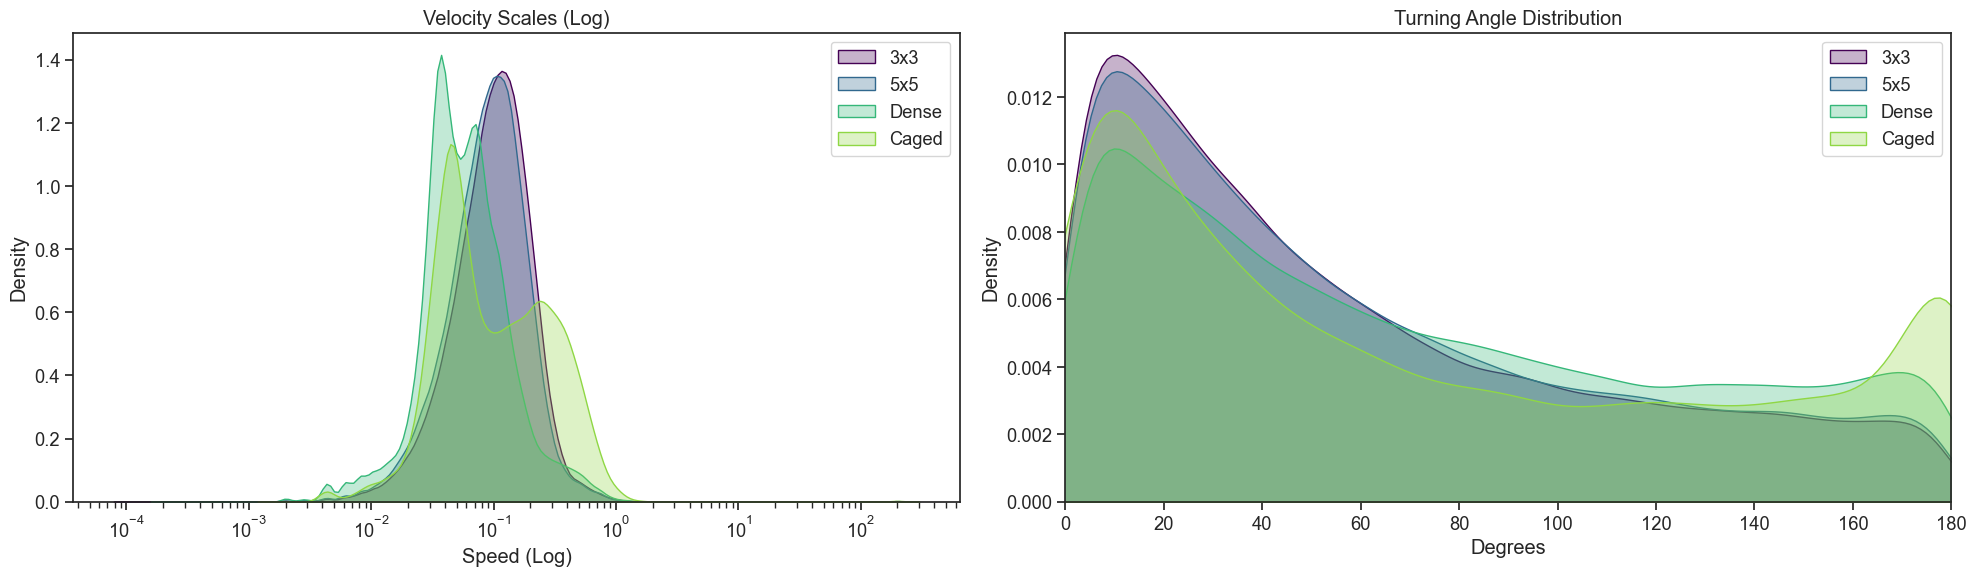

In [9]:
results = {
     '3x3': data_3x3,
     '5x5': data_5x5,
     'Dense': data_limit,
     'Caged': data_dense
}
plot_analysis(results)